<h1 style="font-size: 30px; font-weight: bold">Global Terrorist Data Analysis</h1>
<h2>Analyst: Ryom James Alemania</h2>

<h1 style="font-size: 35px; font-weight: bold;">#1. Data Preparation</h1>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
from IPython.display import display, HTML
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings("ignore")

In [2]:
def print(*args, sep=' ', end='\n', **kwargs):
    output = sep.join(map(str, args)) + end
    styled_output = f'<p style="font-size: 20px;">{output}</p>'
    display(HTML(styled_output))

In [3]:
GT = pd.read_csv("datasets/Global_terrorist.csv", encoding= 'ISO-8859-1')

<h1 style="font-size: 35px; font-weight: bold";>#2 Data Cleansing</h1>

In [4]:
# GT["longitude"].mode()
# GT["latitude"].mode()

In [5]:
# GT["longitude"]= GT["longitude"].fillna(GT["longitude"].mode()[0])
# GT["latitude"]= GT["latitude"].fillna(GT["latitude"].mode()[0])

In [6]:
GT["iyear"]=GT["iyear"].astype("category")
GT["imonth"]=GT["imonth"].astype("category")
GT["iday"]=GT["iyear"].astype("category")
GT["latitude"]=GT["latitude"].astype("float")
GT["longitude"]=GT["longitude"].astype("float")

<h1 style="font-size: 35px; font-weight: bold";>#3 Insights</h1>


In [7]:
!pip install folium

Defaulting to user installation because normal site-packages is not writeable


<p style="font-size: 20px; font-weight: bold;">1. Concentration of Terrorism in Iraq in  2017</p>

In [8]:
GT_2017 = GT[GT['iyear'] == 2017]

In [9]:
Iraq_2017 = GT_2017[GT_2017['country_txt'] == 'Iraq']


In [10]:
Iraq_2017 = Iraq_2017.dropna(subset=['latitude', 'longitude'])


In [11]:
import folium
from folium.plugins import HeatMap

In [12]:
map_center = [Iraq_2017['latitude'].mean(), Iraq_2017['longitude'].mean()]
base_map = folium.Map(location=map_center, zoom_start=10)

heat_data = Iraq_2017[['latitude', 'longitude']].values.tolist()
HeatMap(heat_data).add_to(base_map)

base_map

In [17]:
print("In 2017, terrorist incidents were largely concentrated in Northern Iraq, especially along the borders with Syria, Turkey, and Iran, while the southern and central regions saw far less activity.")

<p style="font-size: 20px; font-weight: bold;">2. Incidents per month in Iraq in  2017</p>

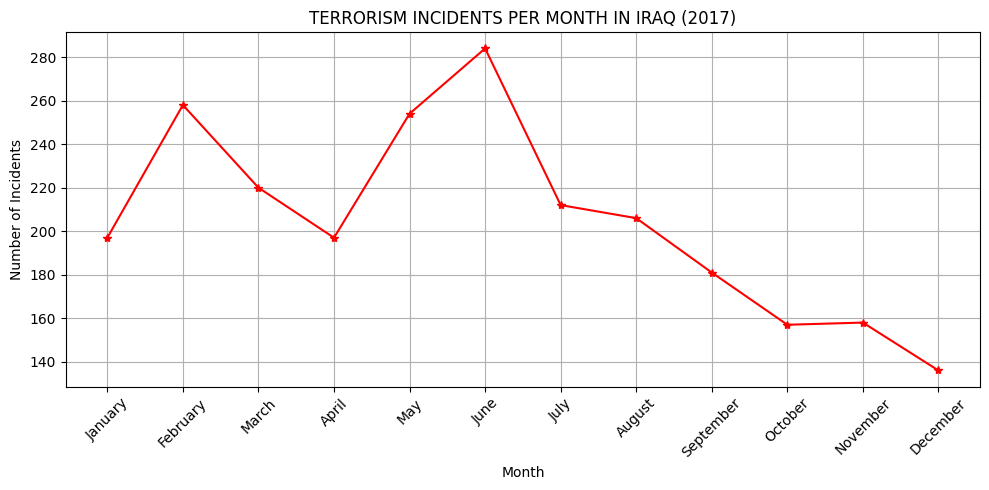

In [29]:
months = ['January', 'February', 'March', 'April', 'May', 'June',
          'July', 'August', 'September', 'October', 'November', 'December']


monthly_counts = Iraq_2017['imonth'].value_counts().reindex(range(1, 13), fill_value=0)


plt.figure(figsize=(10, 5))
plt.plot(months, monthly_counts.values, marker='*',color='red')
plt.title('TERRORISM INCIDENTS PER MONTH IN IRAQ (2017)')
plt.xlabel('Month')
plt.ylabel('Number of Incidents')
plt.xticks(months, rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
print("The graph shows that June in 2017 has the highest number of terrorism in Iraq")

In [21]:
from scipy.stats import chisquare

monthly_counts = Iraq_2017['imonth'].value_counts().reindex(range(1, 13), fill_value=0)

chi2_stat, p_value = chisquare(monthly_counts)


if p_value < 0.05:
    print("✅ There is a statistically significant difference in incidents across months.")
else:
    print("❌ No significant difference in incidents across months.")


<p style="font-size: 20px; font-weight: bold;">3. Concentration of Terrorism in Iraq in  2016</p>

In [31]:
GT_2016 = GT[GT['iyear'] == 2016]


In [32]:
Iraq_2016 = GT_2016[GT_2016['country_txt'] == 'Iraq']


In [33]:
Iraq_2016 = Iraq_2016.dropna(subset=['latitude', 'longitude'])


In [34]:
map_center2 = [Iraq_2016['latitude'].mean(), Iraq_2016['longitude'].mean()]
base_map2 = folium.Map(location=map_center2, zoom_start=15)

heat_data2 = Iraq_2016[['latitude', 'longitude']].values.tolist()
HeatMap(heat_data2).add_to(base_map2)

base_map2

In [35]:
print("Northern Iraq experienced the highest frequency of attacks, a trend that continued from 2017, but with a rise in the number of incidents.")

<p style="font-size: 20px; font-weight: bold;">4. Terrorist incidents in Iraq during 2016</p>

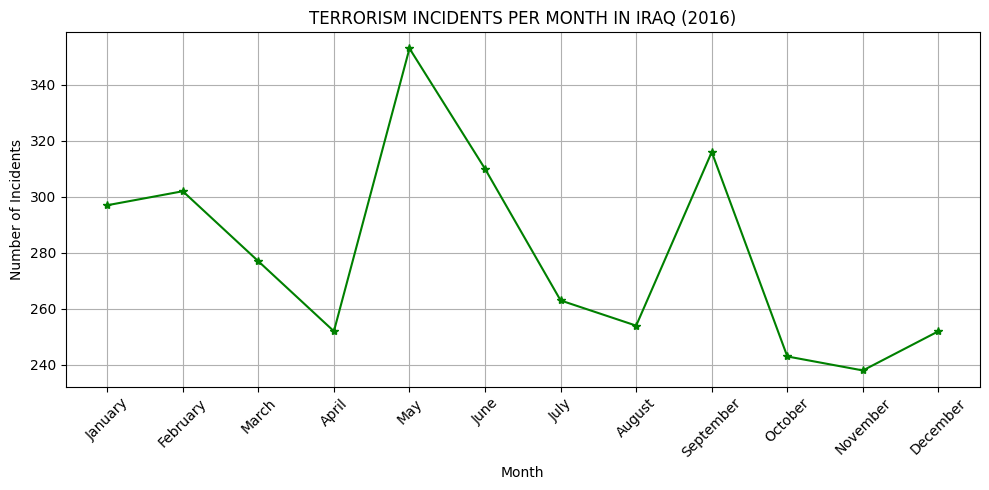

In [39]:
months = ['January', 'February', 'March', 'April', 'May', 'June',
          'July', 'August', 'September', 'October', 'November', 'December']


monthly_counts2 = Iraq_2016['imonth'].value_counts().reindex(range(1, 13), fill_value=0)


plt.figure(figsize=(10, 5))
plt.plot(months, monthly_counts2.values, marker='*',color='green')
plt.title('TERRORISM INCIDENTS PER MONTH IN IRAQ (2016)')
plt.xlabel('Month')
plt.ylabel('Number of Incidents')
plt.xticks(months, rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [40]:
print("The highest number of incidents occurred in May, likely due to the favorable weather conditions, which are ideal for terrorist activities.")

In [41]:

monthly_counts2 = Iraq_2016['imonth'].value_counts().reindex(range(1, 13), fill_value=0)
chi2_stat2, p_value2 = chisquare(monthly_counts2)


if p_value2 < 0.05:
    print("✅ There is a statistically significant variation in incidents across the months. As in 2017, terrorism incidents are unevenly distributed throughout the year.")
else:
    print("❌ There is no statistically significant difference in the number of incidents across the months, indicating a relatively uniform distribution throughout the year.")


<p style="font-size: 20px; font-weight: bold;">5. Comparison of 2016 and 2017 in terms of frequency of Terrorism incidents</p>

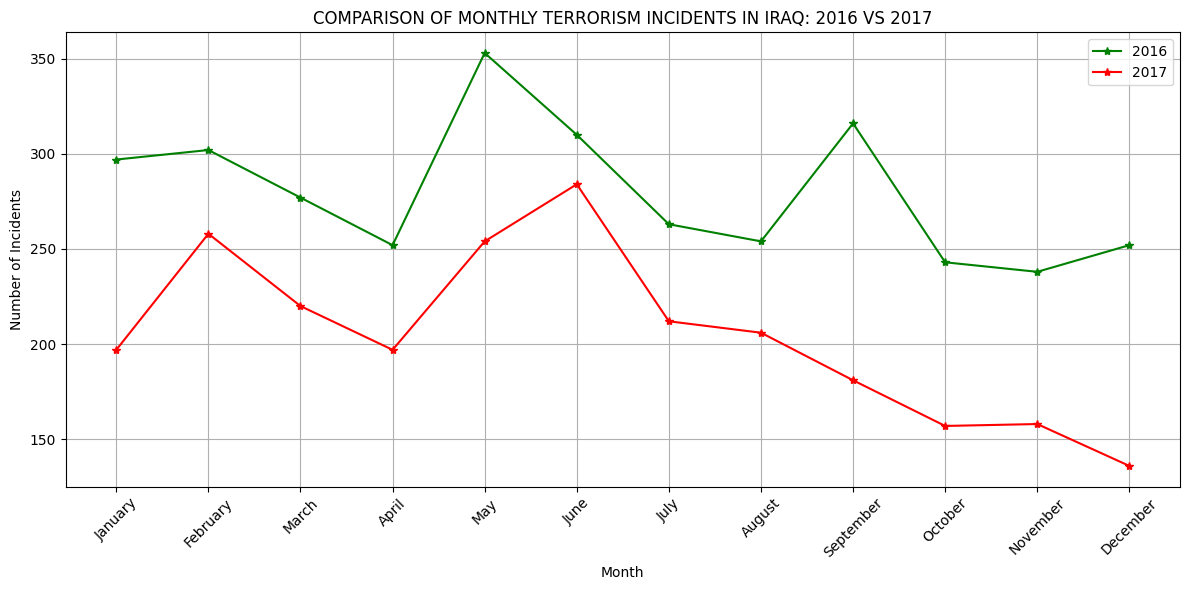

In [44]:
months = ['January', 'February', 'March', 'April', 'May', 'June',
          'July', 'August', 'September', 'October', 'November', 'December']


monthly_counts_2016 = Iraq_2016['imonth'].value_counts().reindex(range(1, 13), fill_value=0)
monthly_counts_2017 = Iraq_2017['imonth'].value_counts().reindex(range(1, 13), fill_value=0)

plt.figure(figsize=(12, 6))
plt.plot(months, monthly_counts_2016.values, marker='*', label='2016', color='green')
plt.plot(months, monthly_counts_2017.values, marker='*', label='2017', color='red')

plt.title('COMPARISON OF MONTHLY TERRORISM INCIDENTS IN IRAQ: 2016 VS 2017')
plt.xlabel('Month')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
print("It can be concluded that the decline in terrorist incidents in Iraq was likely driven by enhanced intelligence operations, strengthened border security, and improved coordination among law enforcement agencies, all of which hindered the ability of terrorist groups to carry out attacks.")
